In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
from tensorflow.keras.utils import image_dataset_from_directory

In [ ]:
training_set = image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 76515 files belonging to 4 classes.


In [3]:
validation_set = image_dataset_from_directory(
    'val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 21861 files belonging to 4 classes.


In [4]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [5]:
INPUT_SHAPE = (224, 224, 3)

In [6]:
mobnet = tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True,
    # name="MobileNetV3Large",
)

In [7]:
model = tf.keras.models.Sequential()

In [8]:
model.add(tf.keras.Input(shape=INPUT_SHAPE))

In [9]:
model.add(mobnet)

In [10]:
model.add(tf.keras.layers.Dense(units = 4,activation='softmax'))

In [11]:
metrics_list = ['accuracy']

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=metrics_list
)

In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense (Dense)               (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [14]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=15)



Epoch 1/15
2392/2392 [==============================] - 736s 302ms/step - loss: 1.1357 - accuracy: 0.8685 - val_loss: 0.9735 - val_accuracy: 0.8980
Epoch 2/15
2392/2392 [==============================] - 380s 159ms/step - loss: 0.8409 - accuracy: 0.8969 - val_loss: 0.7231 - val_accuracy: 0.8988
Epoch 3/15
2392/2392 [==============================] - 378s 158ms/step - loss: 0.6343 - accuracy: 0.9088 - val_loss: 0.5569 - val_accuracy: 0.9554
Epoch 4/15
2392/2392 [==============================] - 380s 159ms/step - loss: 0.4886 - accuracy: 0.9604 - val_loss: 0.4294 - val_accuracy: 0.9613
Epoch 5/15
2392/2392 [==============================] - 380s 158ms/step - loss: 0.3814 - accuracy: 0.9629 - val_loss: 0.3425 - val_accuracy: 0.9591
Epoch 6/15
2392/2392 [==============================] - 379s 158ms/step - loss: 0.2968 - accuracy: 0.9689 - val_loss: 0.2706 - val_accuracy: 0.9665
Epoch 7/15
2392/2392 [==============================] - 381s 159ms/step - loss: 0.2348 - accuracy: 0.9723 - val_

In [15]:
model.save("Trained_Model.h5")


In [16]:
model.save("Trained_Model.keras")

In [17]:
training_history.history

{'loss': [1.1357334852218628,
  0.8409382104873657,
  0.6342881917953491,
  0.4886045753955841,
  0.38142937421798706,
  0.29676368832588196,
  0.23482415080070496,
  0.18393735587596893,
  0.14800569415092468,
  0.11918678879737854,
  0.0985083058476448,
  0.08309902995824814,
  0.07095491886138916,
  0.062324922531843185,
  0.05597565323114395],
 'accuracy': [0.8684702515602112,
  0.8969221711158752,
  0.9088152647018433,
  0.9603737592697144,
  0.9628961682319641,
  0.9689472913742065,
  0.9723191261291504,
  0.9771155714988708,
  0.9800823330879211,
  0.9833104610443115,
  0.9850225448608398,
  0.9873096942901611,
  0.9887603521347046,
  0.9898320436477661,
  0.990302562713623],
 'val_loss': [0.9734727740287781,
  0.7230564951896667,
  0.556949257850647,
  0.4294257164001465,
  0.3425159454345703,
  0.27057212591171265,
  0.21726609766483307,
  0.1849527657032013,
  0.15112191438674927,
  0.24009296298027039,
  0.12230975925922394,
  0.12072716653347015,
  0.11466997116804123,
  0.

In [18]:
# Saving History in pkl file
with open('Training_history.pkl', 'wb') as f:
    pickle.dump(training_history.history, f)

In [19]:
#loading training history from pkl file
with open('Training_history.pkl', 'rb') as f:
    load_history = pickle.load(f)
load_history

{'loss': [1.1357334852218628,
  0.8409382104873657,
  0.6342881917953491,
  0.4886045753955841,
  0.38142937421798706,
  0.29676368832588196,
  0.23482415080070496,
  0.18393735587596893,
  0.14800569415092468,
  0.11918678879737854,
  0.0985083058476448,
  0.08309902995824814,
  0.07095491886138916,
  0.062324922531843185,
  0.05597565323114395],
 'accuracy': [0.8684702515602112,
  0.8969221711158752,
  0.9088152647018433,
  0.9603737592697144,
  0.9628961682319641,
  0.9689472913742065,
  0.9723191261291504,
  0.9771155714988708,
  0.9800823330879211,
  0.9833104610443115,
  0.9850225448608398,
  0.9873096942901611,
  0.9887603521347046,
  0.9898320436477661,
  0.990302562713623],
 'val_loss': [0.9734727740287781,
  0.7230564951896667,
  0.556949257850647,
  0.4294257164001465,
  0.3425159454345703,
  0.27057212591171265,
  0.21726609766483307,
  0.1849527657032013,
  0.15112191438674927,
  0.24009296298027039,
  0.12230975925922394,
  0.12072716653347015,
  0.11466997116804123,
  0.

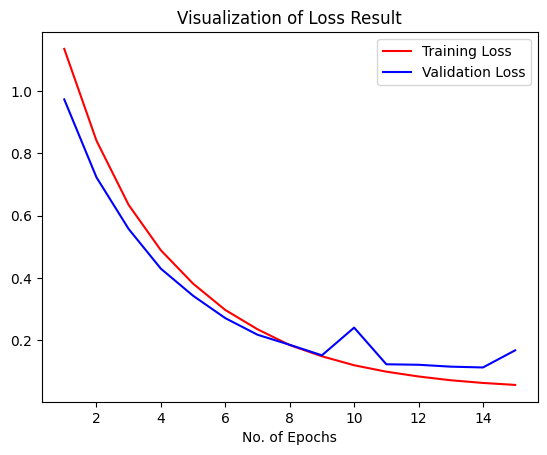

In [20]:
#Loss Visualization
epochs = [i for i in range(1,16)]
plt.plot(epochs,load_history['loss'],color='red',label='Training Loss')
plt.plot(epochs,load_history['val_loss'],color='blue',label='Validation Loss')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Loss Result')
plt.legend()
plt.show()

### Model Evolution

In [21]:
import os
print(os.path.exists("Trained_Model.h5"))

True


In [22]:
import os
print(os.getcwd())

d:\abcd\Dataset - train+val+test


In [23]:
model.load_weights("Trained_Model.h5")

In [24]:
model = tf.keras.models.load_model("Trained_Model.h5")

In [25]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense (Dense)               (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [26]:
test_set = image_dataset_from_directory(
    './test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10933 files belonging to 4 classes.


In [27]:
test_loss, test_acc = model.evaluate(test_set)

342/342 [==============================] - 22s 59ms/step - loss: 0.1781 - accuracy: 0.9502


In [28]:
test_loss, test_acc

(0.17807598412036896, 0.9502424001693726)

In [29]:
##Computing True labels from test set
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [30]:
true_categories

<tf.Tensor: shape=(10933, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], dtype=float32)>

In [31]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [32]:
##Computing Predicted labels using test set
predicted_categories = model.predict(test_set)
Y_pred = tf.argmax(predicted_categories, axis=1)

342/342 [==============================] - 15s 38ms/step


In [33]:
Y_pred

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [34]:
from sklearn.metrics import classification_report
print(classification_report(Y_true,Y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.96      3746
           1       0.79      0.98      0.87      1161
           2       0.88      0.87      0.87       887
           3       0.99      0.97      0.98      5139

    accuracy                           0.95     10933
   macro avg       0.91      0.94      0.92     10933
weighted avg       0.96      0.95      0.95     10933



In [35]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_true,Y_pred)
cm

array([[3484,  175,   80,    7],
       [   6, 1133,    1,   21],
       [  44,   29,  768,   46],
       [   4,  106,   25, 5004]], dtype=int64)

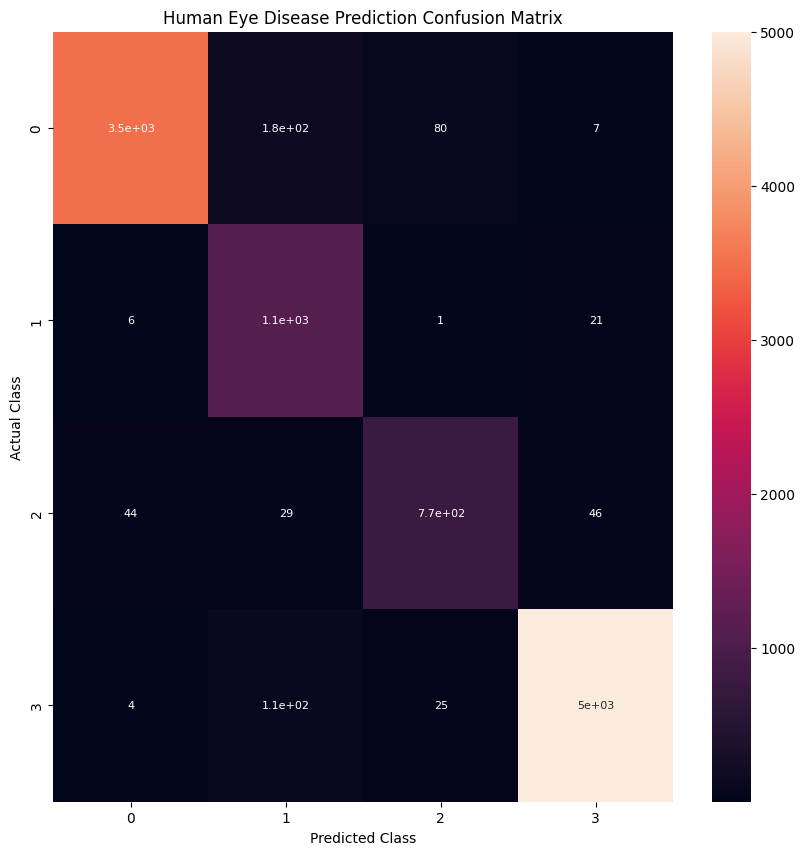

In [36]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={"size":8})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Human Eye Disease Prediction Confusion Matrix",fontsize=12)
plt.show()